## Importy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Ładowanie danych

In [2]:
RENAME_STATIC = {
    'Unnamed: 2': 'Input_tokens', 'Unnamed: 3': 'Output_tokens',
    'Unnamed: 4': 'Cache_read_tokens', 'Unnamed: 5': 'Cache_create_tokens',
    'Unnamed: 6': 'Tokens_summary', 'Unnamed: 7': 'Security_low',
    'Unnamed: 8': 'Security_medium', 'Unnamed: 9': 'Security_high',
    'Unnamed: 10': 'Security_summary', 'Unnamed: 11': 'Reliability_low',
    'Unnamed: 12': 'Reliability_medium', 'Unnamed: 13': 'Reliability_high',
    'Unnamed: 14': 'Reliability_summary', 'Unnamed: 15': 'Maintainability_low',
    'Unnamed: 16': 'Maintainability_medium', 'Unnamed: 17': 'Maintainability_high',
    'Unnamed: 18': 'Maintainability_summary'
}

def load_static(path):
    df = pd.read_csv(path).rename(columns=RENAME_STATIC).drop([0, 1]).reset_index(drop=True)
    numeric_cols = df.columns.drop('Run')
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    parts = df['Run'].str.split('-', expand=True)
    df['Problem'] = parts[0]
    df['REQ'] = parts[1]
    df['Agent'] = parts[2]
    df['Model'] = parts[3].fillna('')
    df['AgentModel'] = df['Agent'] + '-' + df['Model']
    df['SonarQube_total'] = df['Security_summary'] + df['Reliability_summary'] + df['Maintainability_summary']
    return df

copilot_static = load_static('~/SoftwareRequirements/Results/Copilot-static.csv')
fleetrouter_static = load_static('~/SoftwareRequirements/Results/FleetRouter-static.csv')
seatsreservation_static = load_static('~/SoftwareRequirements/Results/SeatsReservation-static.csv')

all_static = pd.concat([copilot_static, fleetrouter_static, seatsreservation_static], ignore_index=True)
print(all_static.shape)
all_static[['Problem', 'REQ', 'AgentModel', 'Pylint score', 'SonarQube_total', 'Cache_create_tokens']].head()

(111, 25)


,Problem,REQ,AgentModel,Pylint score,SonarQube_total,Cache_create_tokens
0,Copilot,REQ1,Claude-Haiku,9.06,1,1016448
1,Copilot,REQ1,Claude-Haiku,9.31,5,1439580
2,Copilot,REQ1,Claude-Haiku,8.96,9,1900930
3,Copilot,REQ1,Claude-Haiku,9.29,1,1291850
4,Copilot,REQ1,Claude-Haiku,8.88,2,1547545


In [3]:
# Functional data – Copilot i FleetRouter mają ScenarioA/B/C; SeatsReservation ma inne kolumny
def load_functional_standard(path, problem_name):
    df = pd.read_csv(path).reset_index(drop=True)
    numeric_cols = df.columns.drop('Run')
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    parts = df['Run'].str.split('-', expand=True)
    df['Problem'] = problem_name
    df['REQ'] = parts[1]
    df['Agent'] = parts[2]
    df['Model'] = parts[3].fillna('')
    df['AgentModel'] = df['Agent'] + '-' + df['Model']
    return df[['Run', 'Problem', 'REQ', 'AgentModel', 'Total failures']]

copilot_functional = load_functional_standard('~/SoftwareRequirements/Results/Copilot-functional.csv', 'Copilot')
fleetrouter_functional = load_functional_standard('~/SoftwareRequirements/Results/FleetRouter-functional.csv', 'FleetRouter')

haiku_func = pd.read_csv('~/SoftwareRequirements/Results/SeatsReservation-haiku-functional.csv',
                         skipinitialspace=True).rename(columns={'Wykonanie': 'Run', 'Suma': 'Total failures'})
haiku_func['AgentModel'] = 'Claude-Haiku'
sonnet_func = pd.read_csv('~/SoftwareRequirements/Results/SeatsReservation-sonnet-functional.csv',
                          skipinitialspace=True).rename(columns={'Wykonanie': 'Run', 'Suma': 'Total failures'})
sonnet_func['AgentModel'] = 'Claude-Sonnet'
sr_func = pd.concat([haiku_func, sonnet_func], ignore_index=True)
sr_func['Problem'] = 'SeatsReservation'
sr_func['REQ'] = sr_func['Run'].str.split('-').str[0]
numeric_cols = sr_func.columns.drop(['Run', 'AgentModel', 'Problem', 'REQ'])
sr_func[numeric_cols] = sr_func[numeric_cols].apply(pd.to_numeric, errors='coerce')
seatsreservation_functional = sr_func[['Run', 'Problem', 'REQ', 'AgentModel', 'Total failures']]

all_functional = pd.concat([copilot_functional, fleetrouter_functional, seatsreservation_functional], ignore_index=True)
all_functional['Total failures'] = pd.to_numeric(all_functional['Total failures'], errors='coerce')
print(all_functional.shape)
all_functional.head()

(102, 5)


,Run,Problem,REQ,AgentModel,Total failures
0,Copilot-REQ1-Claude-Haiku-1,Copilot,REQ1,Claude-Haiku,22.0
1,Copilot-REQ1-Claude-Haiku-2,Copilot,REQ1,Claude-Haiku,45.0
2,Copilot-REQ1-Claude-Haiku-3,Copilot,REQ1,Claude-Haiku,22.0
3,Copilot-REQ1-Claude-Haiku-4,Copilot,REQ1,Claude-Haiku,18.0
4,Copilot-REQ1-Claude-Haiku-5,Copilot,REQ1,Claude-Haiku,22.0


## Analiza statyczna – wyniki zagregowane

### Pylint score – rozkład według problemu i formy specyfikacji

/tmp/ipykernel_2657858/677629211.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)
/tmp/ipykernel_2657858/677629211.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)
/tmp/ipykernel_2657858/677629211.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)


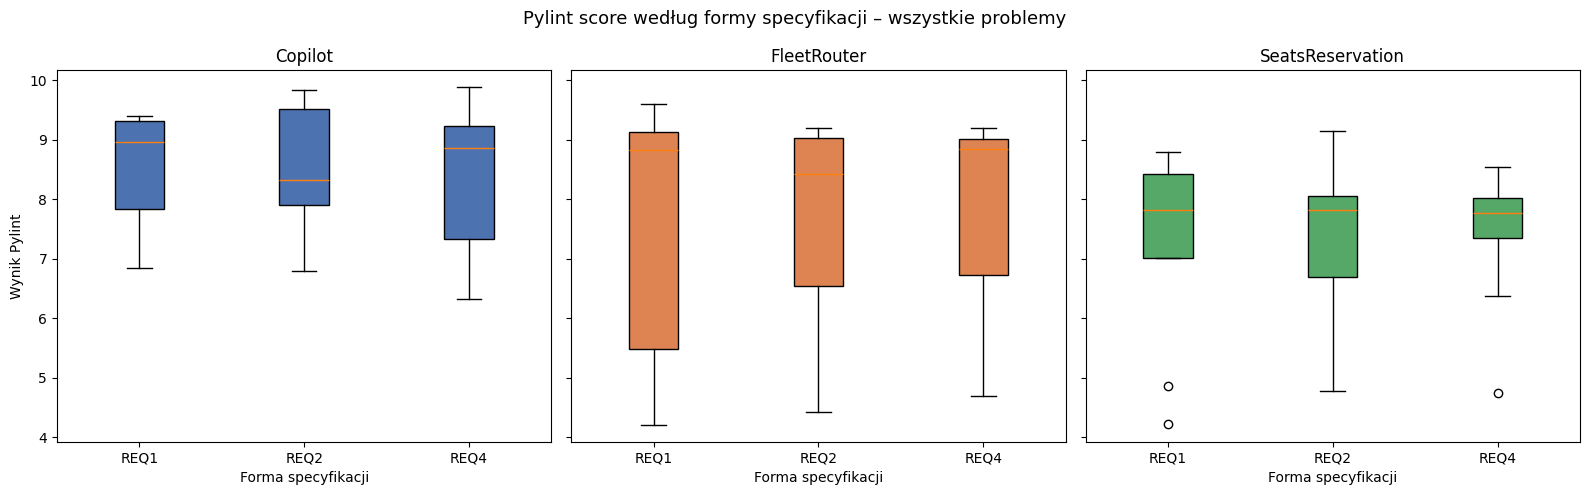

In [4]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, prob, color in zip(axes, problems, colors):
    sub = df[df['Problem'] == prob]
    groups = [sub[sub['REQ'] == req]['Pylint score'].dropna().values for req in req_forms]
    bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    ax.set_title(prob)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Wynik Pylint')

fig.suptitle('Pylint score według formy specyfikacji – wszystkie problemy', fontsize=13)
plt.tight_layout()
plt.show()

### Pylint score – boxplot zbiorczy (wszystkie problemy)

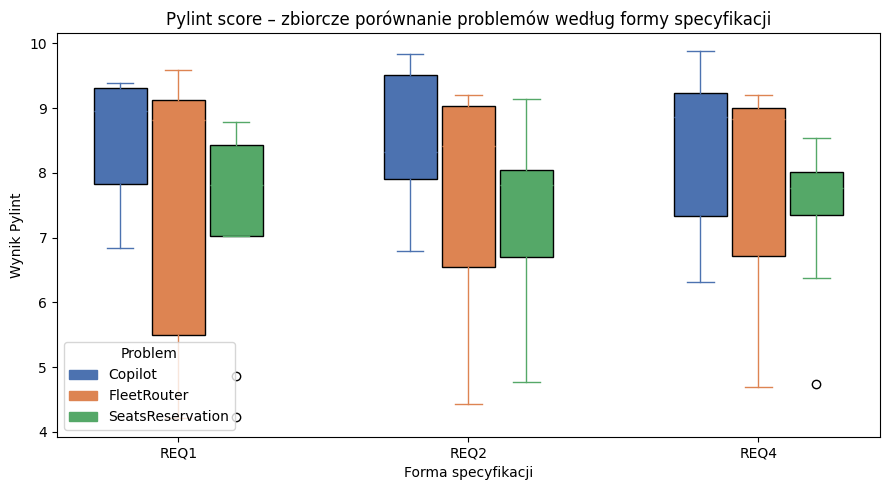

In [5]:
df = all_static.copy()
req_forms = sorted(df['REQ'].dropna().unique())
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))

n_req = len(req_forms)
n_prob = len(problems)
width = 0.6 / n_prob
positions_base = np.arange(1, n_req + 1)

for i, (prob, color) in enumerate(zip(problems, colors)):
    sub = df[df['Problem'] == prob]
    groups = [sub[sub['REQ'] == req]['Pylint score'].dropna().values for req in req_forms]
    positions = positions_base + (i - 1) * width
    bp = ax.boxplot(groups, positions=positions, widths=width * 0.9,
                    patch_artist=True, manage_ticks=False)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    for elem in ['whiskers', 'caps', 'medians', 'fliers']:
        for line in bp[elem]:
            line.set_color(color)

ax.set_xticks(positions_base)
ax.set_xticklabels(req_forms)
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Wynik Pylint')
ax.set_title('Pylint score – zbiorcze porównanie problemów według formy specyfikacji', fontsize=12)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(handles, problems, title='Problem')
plt.tight_layout()
plt.show()

### Pylint score – porównanie problemów (boxplot per problem)

/tmp/ipykernel_2657304/817242639.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=problems, patch_artist=True)


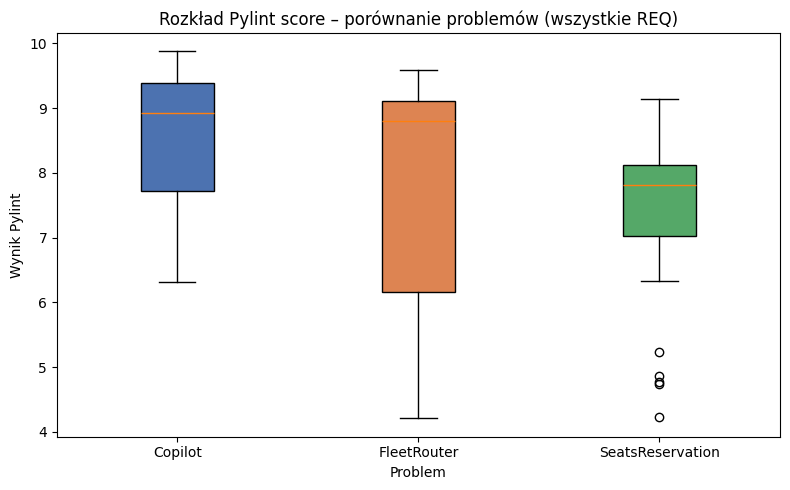

In [6]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']

fig, ax = plt.subplots(figsize=(8, 5))
groups = [df[df['Problem'] == prob]['Pylint score'].dropna().values for prob in problems]
bp = ax.boxplot(groups, labels=problems, patch_artist=True)
colors = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Rozkład Pylint score – porównanie problemów (wszystkie REQ)', fontsize=12)
ax.set_ylabel('Wynik Pylint')
ax.set_xlabel('Problem')
plt.tight_layout()
plt.show()

### SonarQube – łączna liczba problemów według problemu i formy specyfikacji

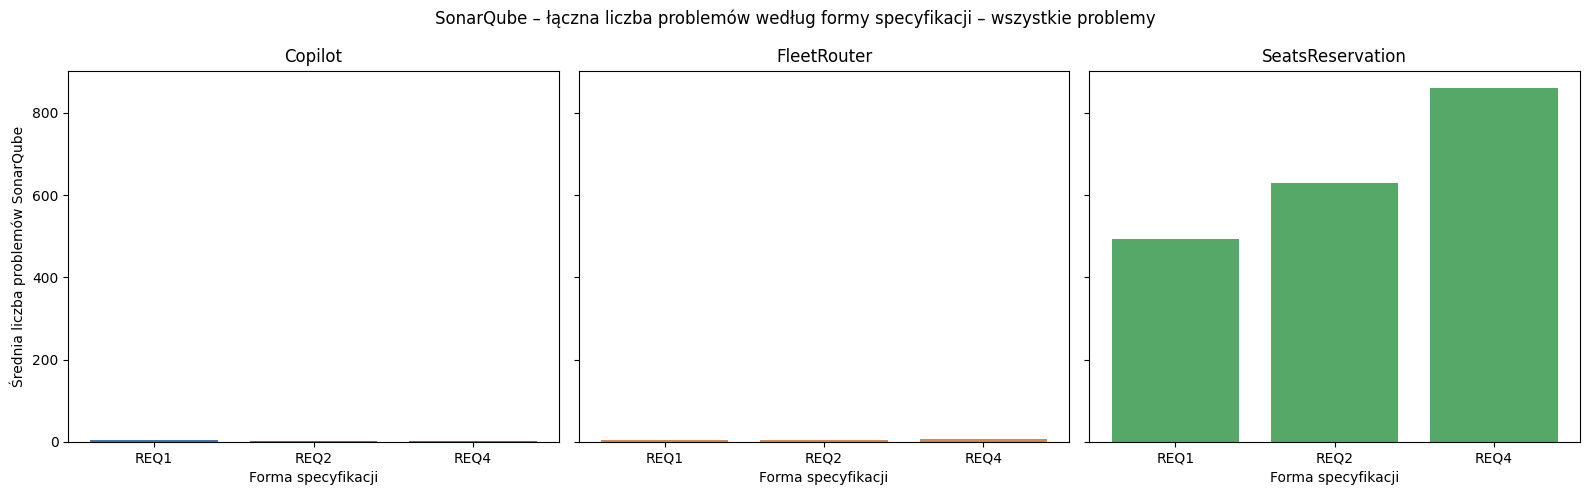

In [7]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, prob, color in zip(axes, problems, colors):
    sub = df[df['Problem'] == prob]
    means = [sub[sub['REQ'] == req]['SonarQube_total'].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means, color=color)
    ax.set_title(prob)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Średnia liczba problemów SonarQube')

fig.suptitle('SonarQube – łączna liczba problemów według formy specyfikacji – wszystkie problemy', fontsize=12)
plt.tight_layout()
plt.show()

### SonarQube – stacked barplot według klas błędów (zbiorczy)

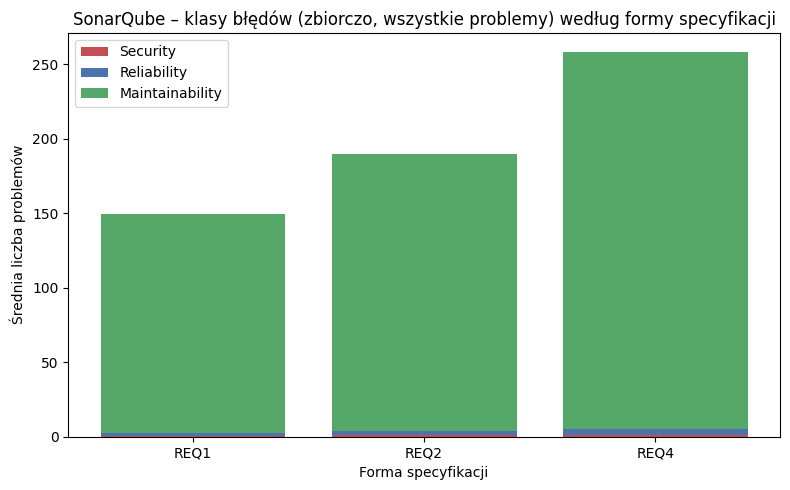

In [8]:
df = all_static.copy()
req_forms = sorted(df['REQ'].dropna().unique())
categories = ['Security_summary', 'Reliability_summary', 'Maintainability_summary']
cat_labels = ['Security', 'Reliability', 'Maintainability']
cat_colors = ['#c44e52', '#4c72b0', '#55a868']

fig, ax = plt.subplots(figsize=(8, 5))
bottoms = [0.0] * len(req_forms)
for cat, label, color in zip(categories, cat_labels, cat_colors):
    means = [df[df['REQ'] == req][cat].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means, bottom=bottoms, label=label, color=color)
    bottoms = [b + m for b, m in zip(bottoms, means)]

ax.set_title('SonarQube – klasy błędów (zbiorczo, wszystkie problemy) według formy specyfikacji', fontsize=12)
ax.set_ylabel('Średnia liczba problemów')
ax.set_xlabel('Forma specyfikacji')
ax.legend()
plt.tight_layout()
plt.show()

### Heatmapa – średni Pylint score (Problem × forma specyfikacji)

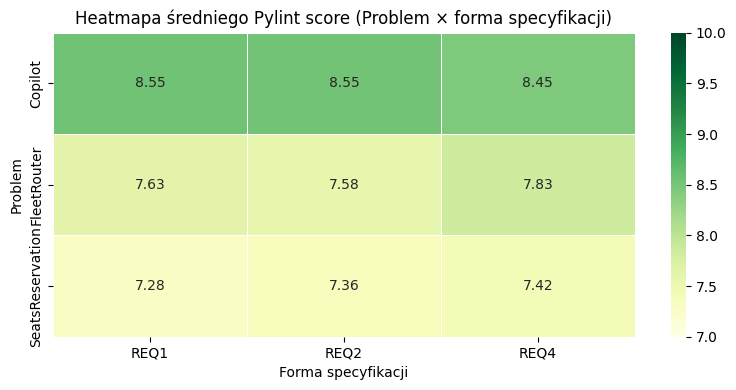

In [9]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())

matrix = [
    [df[(df['Problem'] == prob) & (df['REQ'] == req)]['Pylint score'].dropna().mean()
     for req in req_forms]
    for prob in problems
]
heat_df = pd.DataFrame(matrix, index=problems, columns=req_forms)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlGn', ax=ax, linewidths=0.5, vmin=7, vmax=10)
ax.set_title('Heatmapa średniego Pylint score (Problem × forma specyfikacji)')
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Problem')
plt.tight_layout()
plt.show()

### Heatmapa – średni SonarQube total (Problem × forma specyfikacji)

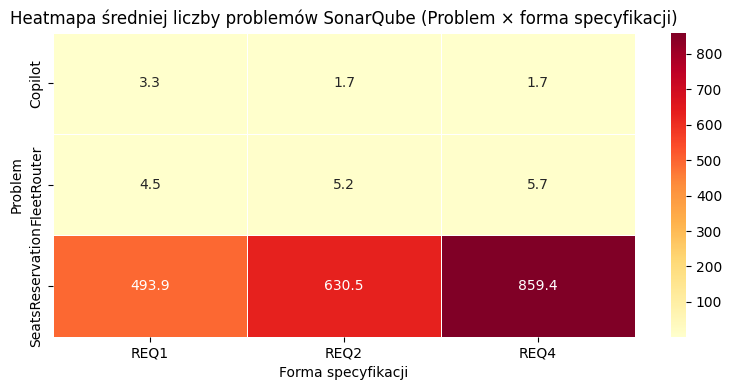

In [10]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())

matrix = [
    [df[(df['Problem'] == prob) & (df['REQ'] == req)]['SonarQube_total'].dropna().mean()
     for req in req_forms]
    for prob in problems
]
heat_df = pd.DataFrame(matrix, index=problems, columns=req_forms)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmapa średniej liczby problemów SonarQube (Problem × forma specyfikacji)')
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Problem')
plt.tight_layout()
plt.show()

## Analiza zużycia tokenów – wyniki zagregowane

### Średnie zużycie tokenów według problemu i formy specyfikacji

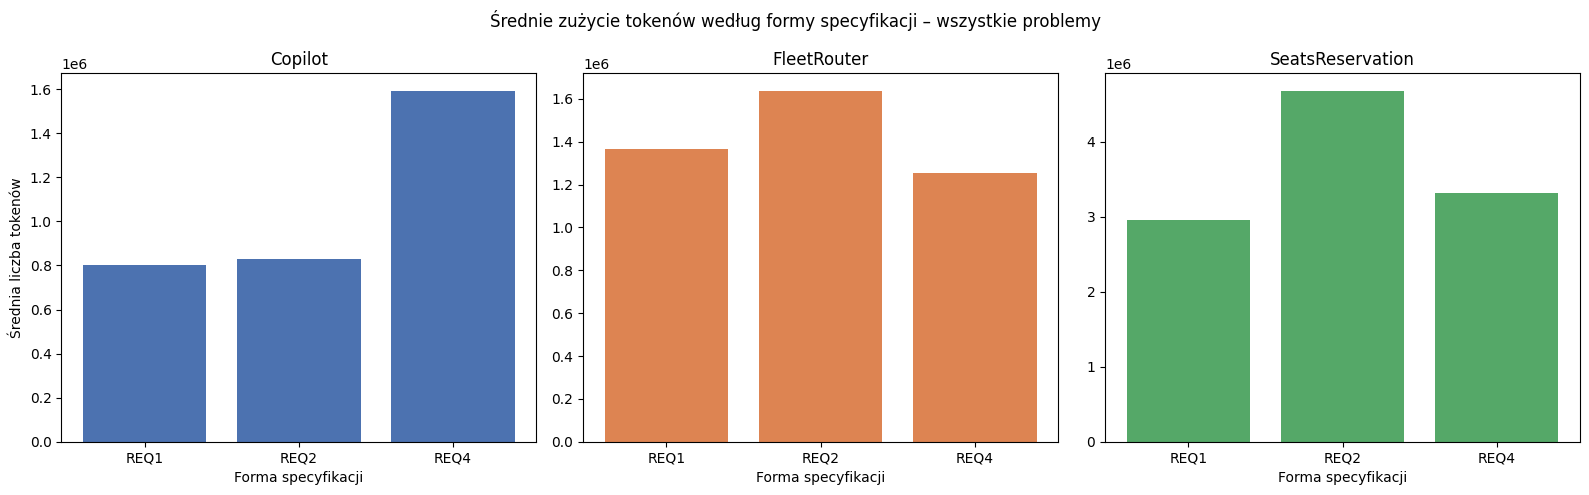

In [11]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, prob, color in zip(axes, problems, colors):
    sub = df[df['Problem'] == prob]
    means = [sub[sub['REQ'] == req]['Cache_create_tokens'].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means, color=color)
    ax.set_title(prob)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Średnia liczba tokenów')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

fig.suptitle('Średnie zużycie tokenów według formy specyfikacji – wszystkie problemy', fontsize=12)
plt.tight_layout()
plt.show()

### Zbiorcze zużycie tokenów (boxplot, wszystkie problemy razem)

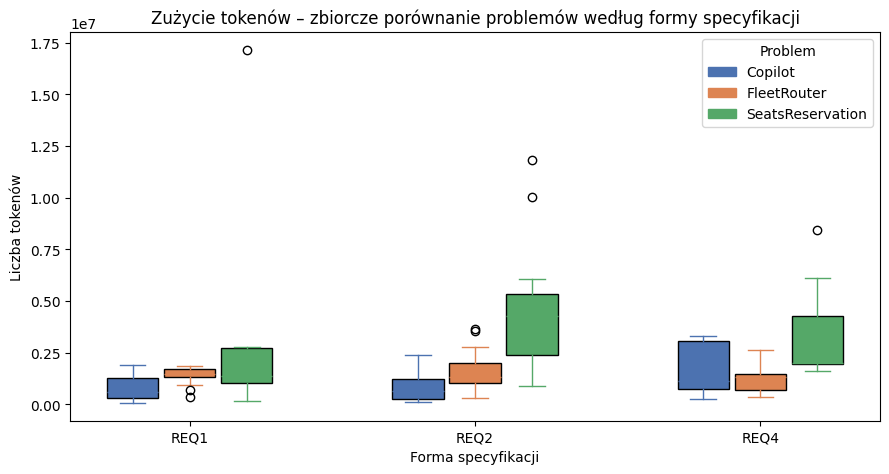

In [12]:
df = all_static.copy()
req_forms = sorted(df['REQ'].dropna().unique())
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
n_req = len(req_forms)
n_prob = len(problems)
width = 0.6 / n_prob
positions_base = np.arange(1, n_req + 1)

for i, (prob, color) in enumerate(zip(problems, colors)):
    sub = df[df['Problem'] == prob]
    groups = [sub[sub['REQ'] == req]['Cache_create_tokens'].dropna().values for req in req_forms]
    positions = positions_base + (i - 1) * width
    bp = ax.boxplot(groups, positions=positions, widths=width * 0.9,
                    patch_artist=True, manage_ticks=False)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    for elem in ['whiskers', 'caps', 'medians', 'fliers']:
        for line in bp[elem]:
            line.set_color(color)

ax.set_xticks(positions_base)
ax.set_xticklabels(req_forms)
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Liczba tokenów')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.set_title('Zużycie tokenów – zbiorcze porównanie problemów według formy specyfikacji', fontsize=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(handles, problems, title='Problem')
plt.tight_layout()
plt.show()

### Heatmapa – średnie zużycie tokenów (Problem × forma specyfikacji)

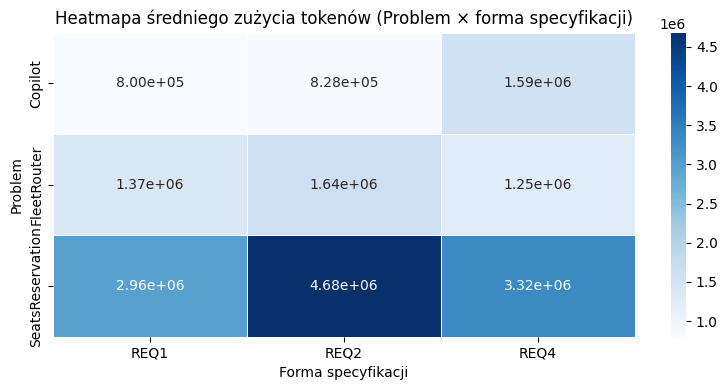

In [13]:
df = all_static.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())

matrix = [
    [df[(df['Problem'] == prob) & (df['REQ'] == req)]['Cache_create_tokens'].dropna().mean()
     for req in req_forms]
    for prob in problems
]
heat_df = pd.DataFrame(matrix, index=problems, columns=req_forms)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_df, annot=True, fmt='.2e', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Heatmapa średniego zużycia tokenów (Problem × forma specyfikacji)')
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Problem')
plt.tight_layout()
plt.show()

### Związek między zużyciem tokenów a wynikiem Pylint (wszystkie problemy)

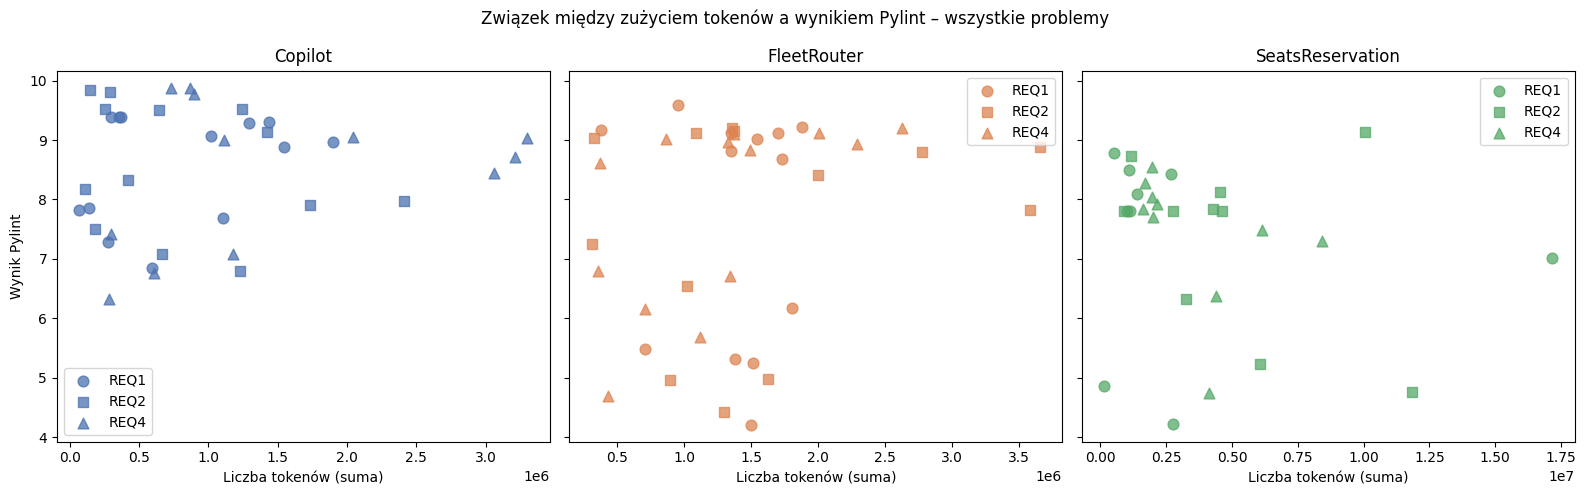

In [14]:
df = all_static.dropna(subset=['Cache_create_tokens', 'Pylint score']).copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
markers = {'REQ1': 'o', 'REQ2': 's', 'REQ4': '^'}
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, prob, color in zip(axes, problems, colors):
    sub = df[df['Problem'] == prob]
    for req in sorted(sub['REQ'].dropna().unique()):
        s = sub[sub['REQ'] == req]
        ax.scatter(s['Cache_create_tokens'], s['Pylint score'],
                   label=req, marker=markers.get(req, 'o'), alpha=0.75, s=60, color=color)
    ax.set_title(prob)
    ax.set_xlabel('Liczba tokenów (suma)')
    if ax == axes[0]:
        ax.set_ylabel('Wynik Pylint')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.legend()

fig.suptitle('Związek między zużyciem tokenów a wynikiem Pylint – wszystkie problemy', fontsize=12)
plt.tight_layout()
plt.show()

## Analiza funkcjonalna – wyniki zagregowane

### Średnia liczba niepokrytych wymagań według problemu i formy specyfikacji

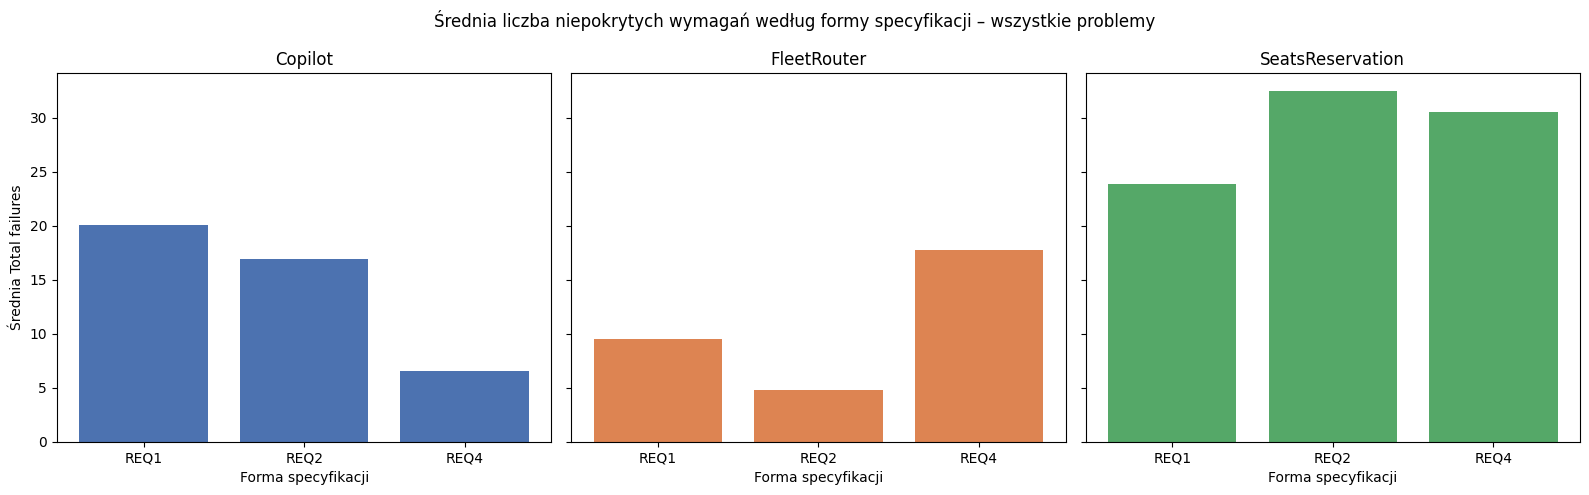

In [15]:
df = all_functional.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, prob, color in zip(axes, problems, colors):
    sub = df[df['Problem'] == prob]
    reqs = sorted(sub['REQ'].dropna().unique())
    means = [sub[sub['REQ'] == req]['Total failures'].dropna().mean() for req in reqs]
    ax.bar(reqs, means, color=color)
    ax.set_title(prob)
    ax.set_xlabel('Forma specyfikacji')
    if ax == axes[0]:
        ax.set_ylabel('Średnia Total failures')

fig.suptitle('Średnia liczba niepokrytych wymagań według formy specyfikacji – wszystkie problemy', fontsize=12)
plt.tight_layout()
plt.show()

### Zbiorcze Total failures – boxplot (wszystkie problemy)

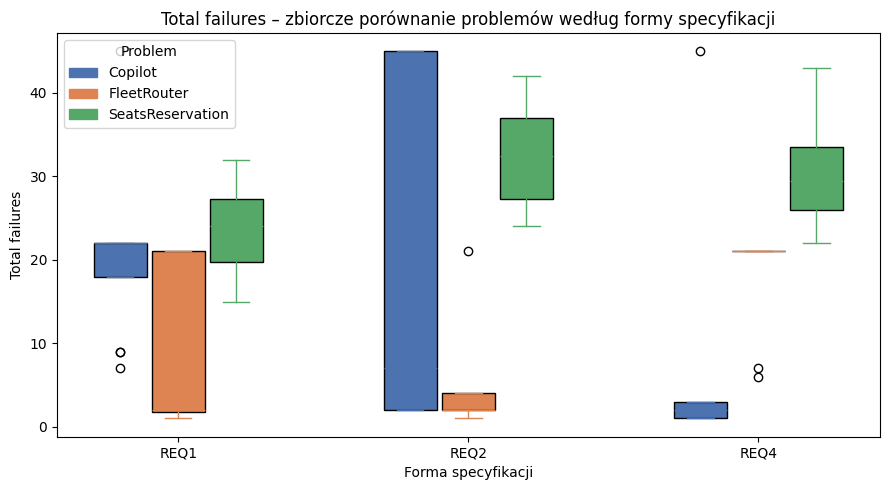

In [16]:
df = all_functional.copy()
req_forms = sorted(df['REQ'].dropna().unique())
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
n_req = len(req_forms)
n_prob = len(problems)
width = 0.6 / n_prob
positions_base = np.arange(1, n_req + 1)

for i, (prob, color) in enumerate(zip(problems, colors)):
    sub = df[df['Problem'] == prob]
    groups = [sub[sub['REQ'] == req]['Total failures'].dropna().values for req in req_forms]
    positions = positions_base + (i - 1) * width
    bp = ax.boxplot(groups, positions=positions, widths=width * 0.9,
                    patch_artist=True, manage_ticks=False)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    for elem in ['whiskers', 'caps', 'medians', 'fliers']:
        for line in bp[elem]:
            line.set_color(color)

ax.set_xticks(positions_base)
ax.set_xticklabels(req_forms)
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Total failures')
ax.set_title('Total failures – zbiorcze porównanie problemów według formy specyfikacji', fontsize=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(handles, problems, title='Problem')
plt.tight_layout()
plt.show()

### Heatmapa – średnie Total failures (Problem × forma specyfikacji)

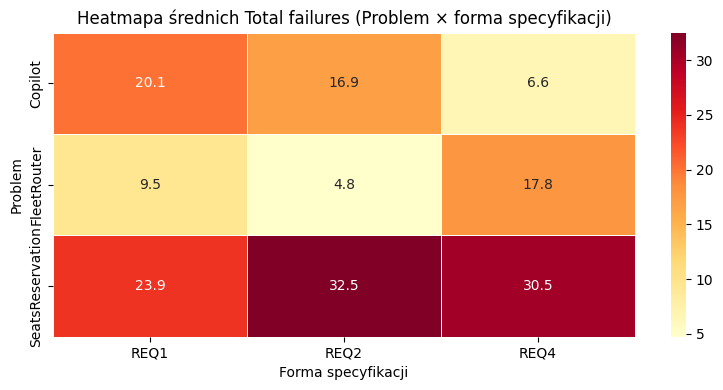

In [17]:
df = all_functional.copy()
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
req_forms = sorted(df['REQ'].dropna().unique())

matrix = [
    [df[(df['Problem'] == prob) & (df['REQ'] == req)]['Total failures'].dropna().mean()
     for req in req_forms]
    for prob in problems
]
heat_df = pd.DataFrame(matrix, index=problems, columns=req_forms)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmapa średnich Total failures (Problem × forma specyfikacji)')
ax.set_xlabel('Forma specyfikacji')
ax.set_ylabel('Problem')
plt.tight_layout()
plt.show()

### Total failures według AgentModel (wszystkie problemy razem)

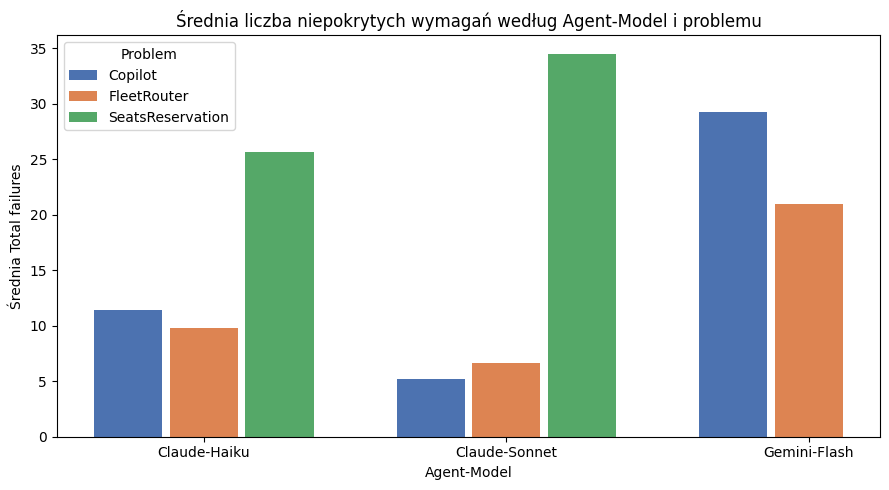

In [18]:
df = all_functional.copy()
agent_models = ['Claude-Haiku', 'Claude-Sonnet', 'Gemini-Flash']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(agent_models))
problems = ['Copilot', 'FleetRouter', 'SeatsReservation']
colors = ['#4C72B0', '#DD8452', '#55A868']
width = 0.25

for i, (prob, color) in enumerate(zip(problems, colors)):
    sub = df[df['Problem'] == prob]
    means = [sub[sub['AgentModel'].str.lower() == am.lower()]['Total failures'].dropna().mean()
             for am in agent_models]
    ax.bar(x + (i - 1) * width, means, width=width * 0.9, label=prob, color=color)

ax.set_xticks(x)
ax.set_xticklabels(agent_models)
ax.set_ylabel('Średnia Total failures')
ax.set_xlabel('Agent-Model')
ax.set_title('Średnia liczba niepokrytych wymagań według Agent-Model i problemu', fontsize=12)
ax.legend(title='Problem')
plt.tight_layout()
plt.show()

## Przegląd zbiorczy – panel wskaźników

/tmp/ipykernel_2657304/3185021123.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)
/tmp/ipykernel_2657304/3185021123.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=req_forms, patch_artist=True)


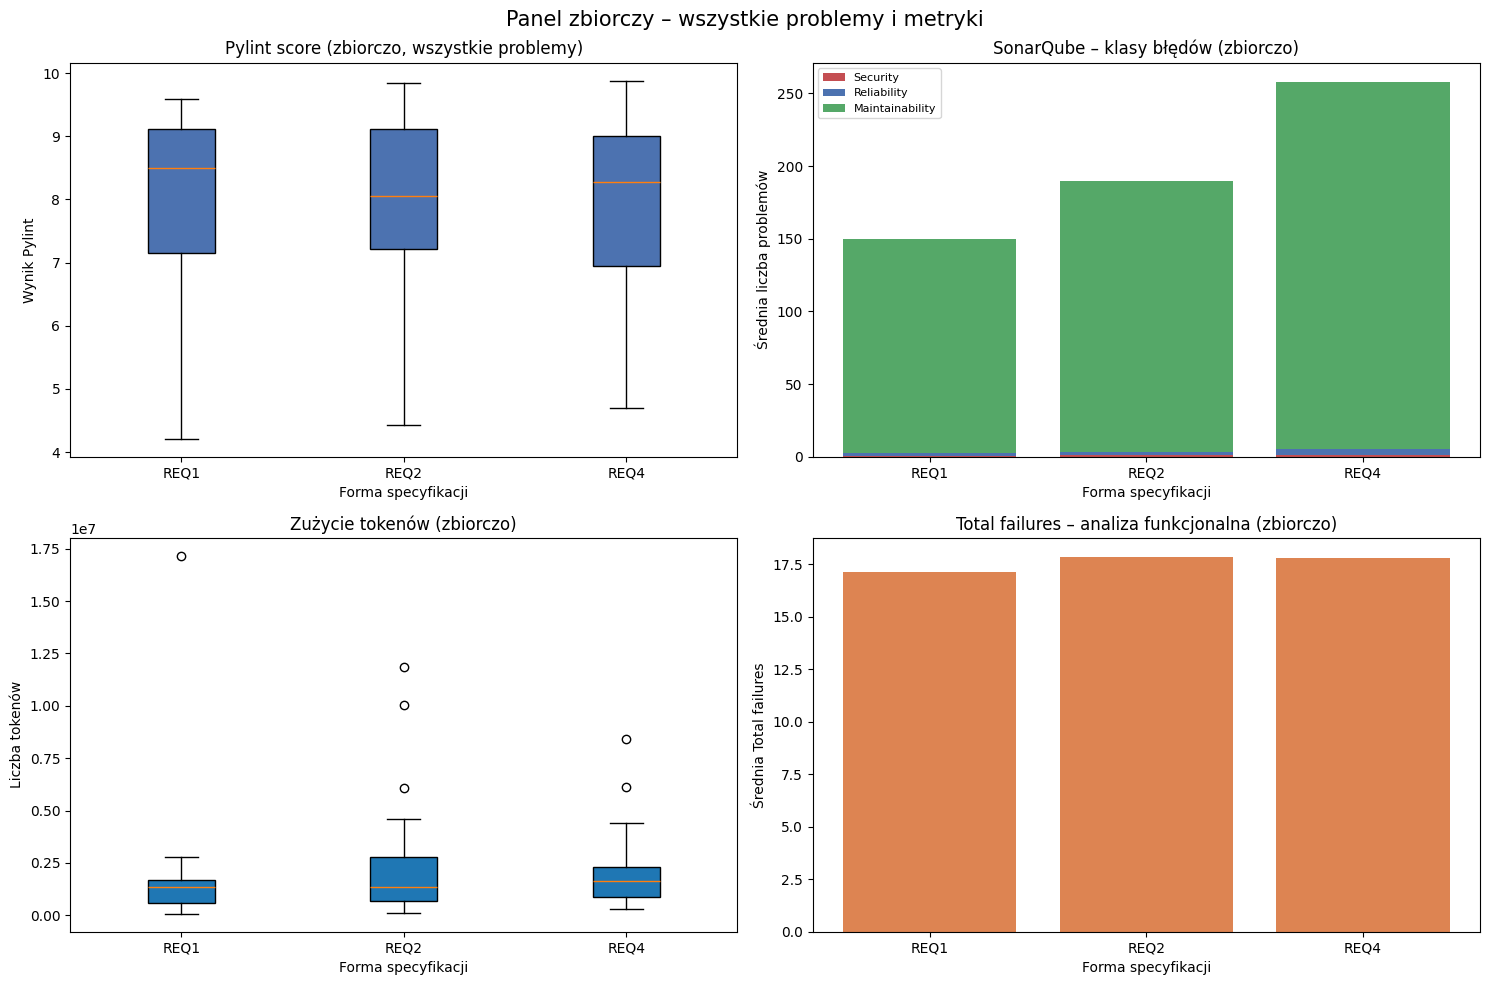

In [19]:
ds = all_static.copy()
df = all_functional.copy()
req_forms = sorted(ds['REQ'].dropna().unique())
cat_colors = ['#c44e52', '#4c72b0', '#55a868']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pylint boxplot
ax = axes[0, 0]
groups = [ds[ds['REQ'] == req]['Pylint score'].dropna().values for req in req_forms]
bp = ax.boxplot(groups, labels=req_forms, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0')
ax.set_title('Pylint score (zbiorczo, wszystkie problemy)')
ax.set_ylabel('Wynik Pylint')
ax.set_xlabel('Forma specyfikacji')

# 2. SonarQube stacked bar
ax = axes[0, 1]
categories = ['Security_summary', 'Reliability_summary', 'Maintainability_summary']
cat_labels = ['Security', 'Reliability', 'Maintainability']
bottoms = [0.0] * len(req_forms)
for cat, label, color in zip(categories, cat_labels, cat_colors):
    means = [ds[ds['REQ'] == req][cat].dropna().mean() for req in req_forms]
    ax.bar(req_forms, means, bottom=bottoms, label=label, color=color)
    bottoms = [b + m for b, m in zip(bottoms, means)]
ax.set_title('SonarQube – klasy błędów (zbiorczo)')
ax.set_ylabel('Średnia liczba problemów')
ax.set_xlabel('Forma specyfikacji')
ax.legend(fontsize=8)

# 3. Token usage boxplot
ax = axes[1, 0]
groups = [ds[ds['REQ'] == req]['Cache_create_tokens'].dropna().values for req in req_forms]
ax.boxplot(groups, labels=req_forms, patch_artist=True)
ax.set_title('Zużycie tokenów (zbiorczo)')
ax.set_ylabel('Liczba tokenów')
ax.set_xlabel('Forma specyfikacji')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# 4. Functional failures bar
ax = axes[1, 1]
means = [df[df['REQ'] == req]['Total failures'].dropna().mean() for req in req_forms]
ax.bar(req_forms, means, color='#DD8452')
ax.set_title('Total failures – analiza funkcjonalna (zbiorczo)')
ax.set_ylabel('Średnia Total failures')
ax.set_xlabel('Forma specyfikacji')

fig.suptitle('Panel zbiorczy – wszystkie problemy i metryki', fontsize=15)
plt.tight_layout()
plt.show()